# Load cleaned issues data

In [ ]:
import os
import pandas as pd

input_dir = "issues-cleanedData"

issues_cleaned_data = {}

for filename in os.listdir(input_dir):
    if filename.endswith(".csv"):
        file_path = os.path.join(input_dir, filename)
        df = pd.read_csv(file_path)

        if all(col in df.columns for col in ['issue_state', 'days_elapsed', 'status']):
            df = df.dropna(subset=['issue_state'])
            
            df = df[['issue_state', 'days_elapsed', 'status']]
            
            issues_cleaned_data[filename[:-11]] = df


issues_cleaned_data['age']


,issue_state,days_elapsed,status
0,CLOSED,4,Graduated
3,CLOSED,21,Graduated
9,CLOSED,1,Graduated
12,CLOSED,7,Graduated
14,CLOSED,287,Graduated
...,...,...,...
4945,CLOSED,9,Graduated
4946,OPEN,24,Graduated
4952,OPEN,12,Graduated
4954,OPEN,12,Graduated


# Import scraper data

In [ ]:
import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler


def clean_csv_files(folder_path):
  cleaned_dataframes = {}

  # List of columns to drop
  columns_to_drop = [
      "status", 
      "emails", "devs", "emails_thread_starter", "emails_thread_starter_word_count",
      "emails_thread_starter_characters", "emails_threads", "emails_threads_word_count",
      "emails_threads_characters", "emails_no_replies", "emails_no_replies_word_count",
      "emails_no_replies_characters", "emails_jira", "most_complex_unit_loc",
      "most_complex_unit_mcabe_index", "total_number_of_files", "number_of_files_main",
      "lines_of_code_main", "number_of_files_test", "lines_of_code_test",
      "test_vs_main_lines_of_code_percentage", "number_of_files_generated",
      "lines_of_code_generated", "number_of_files_build_and_deployment",
      "lines_of_code_build_and_deployment", "negligible_risk_file_size_count",
      "low_risk_file_size_count", "medium_risk_file_size_count", "high_risk_file_size_count",
      "very_high_risk_file_size_count", "negligible_risk_file_size_loc", "low_risk_file_size_loc",
      "medium_risk_file_size_loc", "high_risk_file_size_loc", "very_high_risk_file_size_loc",
      "number_of_units", "lines_of_code_in_units", "lines_of_code_outside_units",
      "unit_size_negligible_risk_loc", "unit_size_negligible_risk_count", "unit_size_low_risk_loc",
      "unit_size_low_risk_count", "unit_size_medium_risk_loc", "unit_size_medium_risk_count",
      "unit_size_high_risk_loc", "unit_size_high_risk_count", "unit_size_very_high_risk_loc",
      "unit_size_very_high_risk_count", "conditional_complexity_negligible_risk_loc",
      "conditional_complexity_negligible_risk_count", "conditional_complexity_low_risk_loc",
      "conditional_complexity_low_risk_count", "conditional_complexity_medium_risk_loc",
      "conditional_complexity_medium_risk_count", "conditional_complexity_high_risk_loc",
      "conditional_complexity_high_risk_count", "conditional_complexity_very_high_risk_loc",
      "conditional_complexity_very_high_risk_count", "conditional_complexity_high_plus_risk_count",
      "conditional_complexity_high_plus_risk_loc", "number_of_contributors",
      "duplication_number_of_duplicates", "duplication_number_of_files_with_duplicates",
      "duplication_number_of_duplicated_lines", "duplication_percentage", "unit_duplicates_count", "releases"
  ]

  for filename in os.listdir(folder_path):
    if filename.endswith(".csv"):
      file_path = os.path.join(folder_path, filename)

      df = pd.read_csv(file_path)

      df = df.drop(
          columns=[col for col in columns_to_drop if col in df.columns], errors='ignore')

      key = os.path.splitext(filename)[0]
      cleaned_dataframes[key] = df

  return cleaned_dataframes

folder_path = "scraper-output"
cleaned_data = clean_csv_files(folder_path)

for key, df in cleaned_data.items():
    for col in df.select_dtypes(include=[np.number]).columns:
        df[col] = df[col].fillna(0)

    if 'programming_lang' in df.columns:
        mode_value = df['programming_lang'].mode()[0] if not df['programming_lang'].mode().empty else 'Unknown'
        
        df['programming_lang'] = df['programming_lang'].fillna(mode_value)
        
        df['programming_lang'] = df['programming_lang'].replace(r'^\s*$', mode_value, regex=True)

status_data = pd.read_csv("project-status.csv")

cleaned_data = {project: df for project,
                df in cleaned_data.items() if len(df) >= 10}

def merge_status(cleaned_data, status_data):
  status_dict = status_data.set_index('project')['status'].to_dict()
  for project, df in cleaned_data.items():
    df['status'] = status_dict.get(project, 'Unknown')
  return cleaned_data

cleaned_data = merge_status(cleaned_data, status_data)

for key, df in cleaned_data.items():
  cleaned_data[key] = df[["commits", "authors",
                                      "committers", "major_contributors", "minor_contributors", "status"]]


# Keep scraper output only for projects for which we have issue data

In [ ]:
issues_cleaned_data_keys = set(issues_cleaned_data.keys())

cleaned_data = {key: value for key, value in cleaned_data.items() if key in issues_cleaned_data_keys}

if 'kiso' in issues_cleaned_data.keys():
    del issues_cleaned_data['kiso'] 

import copy
cleaned_data_transformer = copy.deepcopy(cleaned_data)

print("Filtered cleaned_data:")
print(len(cleaned_data_transformer), len(issues_cleaned_data))
# graduated = 0
# retired = 0
# for df in cleaned_data_transformer.values():
#     if df['status'].iloc[0]=='Graduated':
#         graduated+=1
#     else:
#         retired+=1
# print(graduated, retired)

Filtered cleaned_data:
87 87


In [4]:
cleaned_data_transformer['age']

,commits,authors,committers,major_contributors,minor_contributors,status
0,6,1,1,1,0,Graduated
1,1,1,1,1,0,Graduated
2,0,0,0,0,0,Graduated
3,1,1,1,1,0,Graduated
4,7,3,1,3,0,Graduated
...,...,...,...,...,...,...
63,4,2,1,2,0,Graduated
64,4,3,1,3,0,Graduated
65,6,3,1,3,0,Graduated
66,7,2,1,2,0,Graduated


In [5]:
issues_cleaned_data['age']

,issue_state,days_elapsed,status
0,CLOSED,4,Graduated
3,CLOSED,21,Graduated
9,CLOSED,1,Graduated
12,CLOSED,7,Graduated
14,CLOSED,287,Graduated
...,...,...,...
4945,CLOSED,9,Graduated
4946,OPEN,24,Graduated
4952,OPEN,12,Graduated
4954,OPEN,12,Graduated


# LSTM model on combined issues and scraper data

/Users/shreyasshah/Desktop/UCD/SE/SE-project/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/shreyasshah/Desktop/UCD/SE/SE-project/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using GPU for training.


/Users/shreyasshah/Desktop/UCD/SE/SE-project/.venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/shreyasshah/Desktop/UCD/SE/SE-project/.venv/lib/python3.9/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/Users/shreyasshah/Desktop/UCD/SE/SE-project/.venv/lib/python3.9/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(
/Users/shreyasshah/Desktop/UCD/SE/SE-project/.venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.

Shape of oversampled X1_train: (80, 290, 5)
Shape of oversampled X2_train: (80, 15520, 2)
class weights:  {0: 1.0, 1: 1.0}


2025-03-10 02:21:22.960972: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


Epoch 01 - Train Loss: 0.6932, Train Acc: 0.6000, Val Loss: 0.6938, Val Acc: 0.3333
Epoch 02 - Train Loss: 0.6941, Train Acc: 0.4375, Val Loss: 0.6942, Val Acc: 0.3333
Epoch 03 - Train Loss: 0.6941, Train Acc: 0.4500, Val Loss: 0.6945, Val Acc: 0.3333
Epoch 04 - Train Loss: 0.6945, Train Acc: 0.4625, Val Loss: 0.6948, Val Acc: 0.3333
Epoch 05 - Train Loss: 0.6905, Train Acc: 0.4875, Val Loss: 0.6951, Val Acc: 0.3333
Epoch 06 - Train Loss: 0.6897, Train Acc: 0.4750, Val Loss: 0.6954, Val Acc: 0.3333
Epoch 07 - Train Loss: 0.6968, Train Acc: 0.4625, Val Loss: 0.6957, Val Acc: 0.3333
Epoch 08 - Train Loss: 0.6908, Train Acc: 0.5000, Val Loss: 0.6960, Val Acc: 0.3333
Epoch 09 - Train Loss: 0.6874, Train Acc: 0.5000, Val Loss: 0.6963, Val Acc: 0.3333
Epoch 10 - Train Loss: 0.6835, Train Acc: 0.5000, Val Loss: 0.6966, Val Acc: 0.3333
Epoch 11 - Train Loss: 0.6841, Train Acc: 0.4875, Val Loss: 0.6968, Val Acc: 0.3333
Epoch 12 - Train Loss: 0.6771, Train Acc: 0.5000, Val Loss: 0.6970, Val Acc:

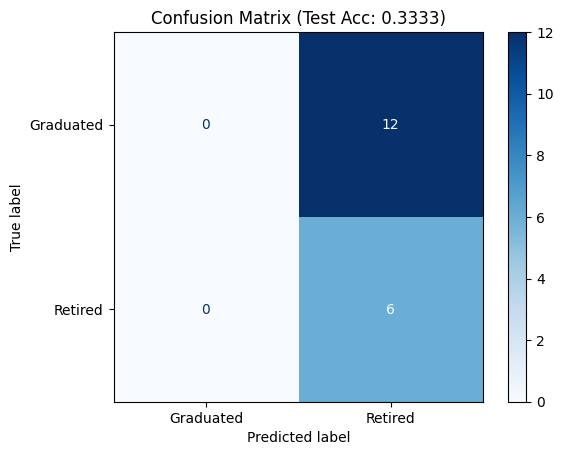

[I 2025-03-10 02:23:24,929] Trial 0 finished with value: 0.6666666567325592 and parameters: {'learning_rate': 0.0001329291894316216, 'dropout_rate': 0.4802857225639665, 'weight_decay': 0.000157029708840554}. Best is trial 0 with value: 0.6666666567325592.
/var/folders/7g/xvz8wfd9477_ywln21gwjvdr0000gn/T/ipykernel_32054/4043238553.py:102: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  learning_rate = trial.suggest_loguniform('learning_rate', 1e-5, 1e-2)
/var/folders/7g/xvz8wfd9477_ywln21gwjvdr0000gn/T/ipykernel_32054/4043238553.py:103: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  dropout_rate = trial.suggest_uniform('dropout_rate', 0.1, 0.5)
/var/folders/7g/xvz8wfd9477_ywln21gwjvdr0000gn/

Epoch 01 - Train Loss: 0.6969, Train Acc: 0.4750, Val Loss: 0.6956, Val Acc: 0.3333
Epoch 02 - Train Loss: 0.6980, Train Acc: 0.4250, Val Loss: 0.6969, Val Acc: 0.3333
Epoch 03 - Train Loss: 0.6959, Train Acc: 0.4250, Val Loss: 0.6976, Val Acc: 0.3333
Epoch 04 - Train Loss: 0.6941, Train Acc: 0.4375, Val Loss: 0.6980, Val Acc: 0.3333
Epoch 05 - Train Loss: 0.6912, Train Acc: 0.5000, Val Loss: 0.6985, Val Acc: 0.3333
Epoch 06 - Train Loss: 0.6919, Train Acc: 0.5000, Val Loss: 0.6992, Val Acc: 0.3333
Epoch 07 - Train Loss: 0.6891, Train Acc: 0.5000, Val Loss: 0.7000, Val Acc: 0.3333
Epoch 08 - Train Loss: 0.6912, Train Acc: 0.4750, Val Loss: 0.7008, Val Acc: 0.3333
Epoch 09 - Train Loss: 0.6854, Train Acc: 0.5125, Val Loss: 0.7016, Val Acc: 0.3333
Epoch 10 - Train Loss: 0.6856, Train Acc: 0.5125, Val Loss: 0.7024, Val Acc: 0.3333
Epoch 11 - Train Loss: 0.6841, Train Acc: 0.5125, Val Loss: 0.7029, Val Acc: 0.3333
Epoch 12 - Train Loss: 0.6842, Train Acc: 0.5000, Val Loss: 0.7031, Val Acc:

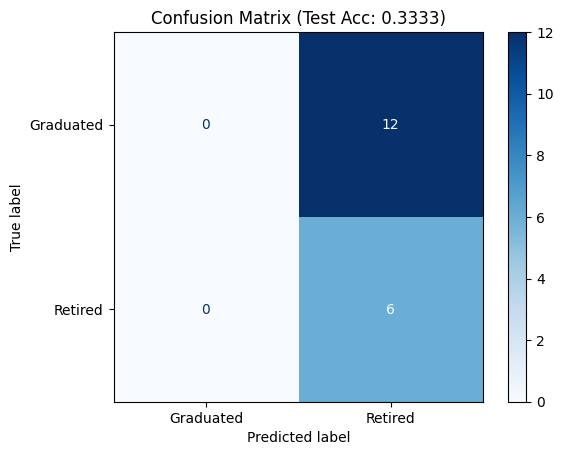

[I 2025-03-10 02:25:10,136] Trial 1 finished with value: 0.6666666567325592 and parameters: {'learning_rate': 0.0006251373574521745, 'dropout_rate': 0.1624074561769746, 'weight_decay': 2.9375384576328313e-06}. Best is trial 0 with value: 0.6666666567325592.
/var/folders/7g/xvz8wfd9477_ywln21gwjvdr0000gn/T/ipykernel_32054/4043238553.py:102: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  learning_rate = trial.suggest_loguniform('learning_rate', 1e-5, 1e-2)
/var/folders/7g/xvz8wfd9477_ywln21gwjvdr0000gn/T/ipykernel_32054/4043238553.py:103: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  dropout_rate = trial.suggest_uniform('dropout_rate', 0.1, 0.5)
/var/folders/7g/xvz8wfd9477_ywln21gwjvdr0000g

Epoch 01 - Train Loss: 0.6996, Train Acc: 0.5000, Val Loss: 0.6932, Val Acc: 0.3333
Epoch 02 - Train Loss: 0.6941, Train Acc: 0.4625, Val Loss: 0.6932, Val Acc: 0.3333
Epoch 03 - Train Loss: 0.6966, Train Acc: 0.4625, Val Loss: 0.6933, Val Acc: 0.3333
Epoch 04 - Train Loss: 0.6983, Train Acc: 0.4500, Val Loss: 0.6933, Val Acc: 0.3333
Epoch 05 - Train Loss: 0.6912, Train Acc: 0.4875, Val Loss: 0.6933, Val Acc: 0.3333
Epoch 06 - Train Loss: 0.6961, Train Acc: 0.4375, Val Loss: 0.6933, Val Acc: 0.3333
Epoch 07 - Train Loss: 0.6945, Train Acc: 0.4750, Val Loss: 0.6933, Val Acc: 0.3333
Epoch 08 - Train Loss: 0.7015, Train Acc: 0.4250, Val Loss: 0.6934, Val Acc: 0.3333
Epoch 09 - Train Loss: 0.6926, Train Acc: 0.4625, Val Loss: 0.6934, Val Acc: 0.3333
Epoch 10 - Train Loss: 0.6992, Train Acc: 0.4125, Val Loss: 0.6934, Val Acc: 0.3333
Epoch 11 - Train Loss: 0.6964, Train Acc: 0.4875, Val Loss: 0.6934, Val Acc: 0.3333
Epoch 12 - Train Loss: 0.6995, Train Acc: 0.4375, Val Loss: 0.6934, Val Acc:

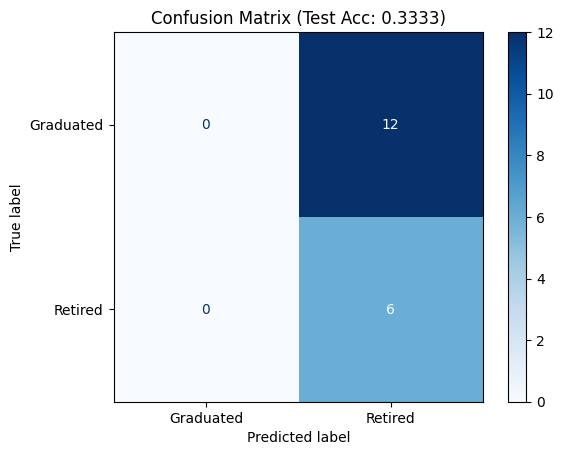

[I 2025-03-10 02:27:01,402] Trial 2 finished with value: 0.6666666567325592 and parameters: {'learning_rate': 1.493656855461762e-05, 'dropout_rate': 0.4464704583099741, 'weight_decay': 6.358358856676247e-05}. Best is trial 0 with value: 0.6666666567325592.
/var/folders/7g/xvz8wfd9477_ywln21gwjvdr0000gn/T/ipykernel_32054/4043238553.py:102: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  learning_rate = trial.suggest_loguniform('learning_rate', 1e-5, 1e-2)
/var/folders/7g/xvz8wfd9477_ywln21gwjvdr0000gn/T/ipykernel_32054/4043238553.py:103: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  dropout_rate = trial.suggest_uniform('dropout_rate', 0.1, 0.5)
/var/folders/7g/xvz8wfd9477_ywln21gwjvdr0000gn

Epoch 01 - Train Loss: 0.6890, Train Acc: 0.5625, Val Loss: 0.6985, Val Acc: 0.3333
Epoch 02 - Train Loss: 0.6843, Train Acc: 0.5000, Val Loss: 0.7008, Val Acc: 0.3333
Epoch 03 - Train Loss: 0.6793, Train Acc: 0.5125, Val Loss: 0.7018, Val Acc: 0.3333
Epoch 04 - Train Loss: 0.6750, Train Acc: 0.5000, Val Loss: 0.7018, Val Acc: 0.3333
Epoch 05 - Train Loss: 0.6683, Train Acc: 0.5000, Val Loss: 0.7015, Val Acc: 0.3333
Epoch 06 - Train Loss: 0.6666, Train Acc: 0.5125, Val Loss: 0.7013, Val Acc: 0.3333
Epoch 07 - Train Loss: 0.6588, Train Acc: 0.5125, Val Loss: 0.7004, Val Acc: 0.3333
Epoch 08 - Train Loss: 0.6531, Train Acc: 0.5125, Val Loss: 0.6986, Val Acc: 0.3333
Epoch 09 - Train Loss: 0.6476, Train Acc: 0.5125, Val Loss: 0.6957, Val Acc: 0.3333
Epoch 10 - Train Loss: 0.6442, Train Acc: 0.5250, Val Loss: 0.6921, Val Acc: 0.6667
Epoch 11 - Train Loss: 0.6419, Train Acc: 0.5125, Val Loss: 0.6879, Val Acc: 0.6667
Epoch 12 - Train Loss: 0.6389, Train Acc: 0.5375, Val Loss: 0.6801, Val Acc:

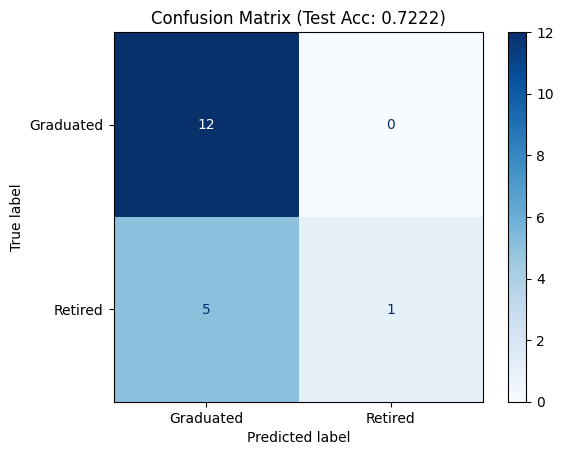

[I 2025-03-10 02:28:55,098] Trial 3 finished with value: 0.2777777910232544 and parameters: {'learning_rate': 0.001331121608073689, 'dropout_rate': 0.10823379771832098, 'weight_decay': 0.0008123245085588687}. Best is trial 3 with value: 0.2777777910232544.
/var/folders/7g/xvz8wfd9477_ywln21gwjvdr0000gn/T/ipykernel_32054/4043238553.py:102: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  learning_rate = trial.suggest_loguniform('learning_rate', 1e-5, 1e-2)
/var/folders/7g/xvz8wfd9477_ywln21gwjvdr0000gn/T/ipykernel_32054/4043238553.py:103: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  dropout_rate = trial.suggest_uniform('dropout_rate', 0.1, 0.5)
/var/folders/7g/xvz8wfd9477_ywln21gwjvdr0000gn

Epoch 01 - Train Loss: 0.6907, Train Acc: 0.6125, Val Loss: 0.7026, Val Acc: 0.3333
Epoch 02 - Train Loss: 0.6839, Train Acc: 0.5125, Val Loss: 0.7063, Val Acc: 0.3333
Epoch 03 - Train Loss: 0.6785, Train Acc: 0.5125, Val Loss: 0.7032, Val Acc: 0.3333
Epoch 04 - Train Loss: 0.6708, Train Acc: 0.5125, Val Loss: 0.7000, Val Acc: 0.3333
Epoch 05 - Train Loss: 0.6619, Train Acc: 0.5125, Val Loss: 0.6939, Val Acc: 0.3333
Epoch 06 - Train Loss: 0.6459, Train Acc: 0.5000, Val Loss: 0.7150, Val Acc: 0.3333
Epoch 07 - Train Loss: 0.6693, Train Acc: 0.5375, Val Loss: 0.6701, Val Acc: 0.6667
Epoch 08 - Train Loss: 0.6390, Train Acc: 0.5750, Val Loss: 0.6610, Val Acc: 0.6667
Epoch 09 - Train Loss: 0.6419, Train Acc: 0.5875, Val Loss: 0.6533, Val Acc: 0.6667
Epoch 10 - Train Loss: 0.6380, Train Acc: 0.5875, Val Loss: 0.6577, Val Acc: 0.6667
Epoch 11 - Train Loss: 0.6367, Train Acc: 0.5875, Val Loss: 0.6621, Val Acc: 0.6667
Epoch 12 - Train Loss: 0.6360, Train Acc: 0.5875, Val Loss: 0.6649, Val Acc:

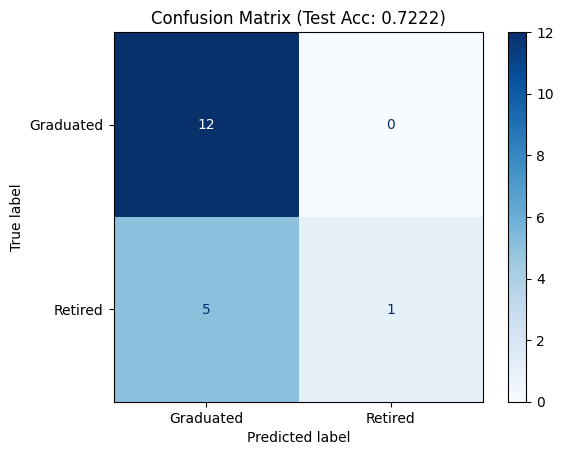

[I 2025-03-10 02:30:57,746] Trial 4 finished with value: 0.2777777910232544 and parameters: {'learning_rate': 0.00314288089084011, 'dropout_rate': 0.18493564427131048, 'weight_decay': 3.5113563139704077e-06}. Best is trial 3 with value: 0.2777777910232544.
/var/folders/7g/xvz8wfd9477_ywln21gwjvdr0000gn/T/ipykernel_32054/4043238553.py:102: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  learning_rate = trial.suggest_loguniform('learning_rate', 1e-5, 1e-2)
/var/folders/7g/xvz8wfd9477_ywln21gwjvdr0000gn/T/ipykernel_32054/4043238553.py:103: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  dropout_rate = trial.suggest_uniform('dropout_rate', 0.1, 0.5)
/var/folders/7g/xvz8wfd9477_ywln21gwjvdr0000gn

Epoch 01 - Train Loss: 0.6907, Train Acc: 0.5250, Val Loss: 0.6932, Val Acc: 0.3333
Epoch 02 - Train Loss: 0.6903, Train Acc: 0.5000, Val Loss: 0.6933, Val Acc: 0.3333
Epoch 03 - Train Loss: 0.6901, Train Acc: 0.5125, Val Loss: 0.6933, Val Acc: 0.3333
Epoch 04 - Train Loss: 0.6898, Train Acc: 0.5000, Val Loss: 0.6933, Val Acc: 0.3333
Epoch 05 - Train Loss: 0.6886, Train Acc: 0.5125, Val Loss: 0.6933, Val Acc: 0.3333
Epoch 06 - Train Loss: 0.6891, Train Acc: 0.5000, Val Loss: 0.6933, Val Acc: 0.3333
Epoch 07 - Train Loss: 0.6924, Train Acc: 0.4250, Val Loss: 0.6934, Val Acc: 0.3333
Epoch 08 - Train Loss: 0.6927, Train Acc: 0.4500, Val Loss: 0.6934, Val Acc: 0.3333
Epoch 09 - Train Loss: 0.6903, Train Acc: 0.5250, Val Loss: 0.6934, Val Acc: 0.3333
Epoch 10 - Train Loss: 0.6902, Train Acc: 0.5375, Val Loss: 0.6934, Val Acc: 0.3333
Epoch 11 - Train Loss: 0.6916, Train Acc: 0.4750, Val Loss: 0.6934, Val Acc: 0.3333
Epoch 12 - Train Loss: 0.6914, Train Acc: 0.5375, Val Loss: 0.6934, Val Acc:

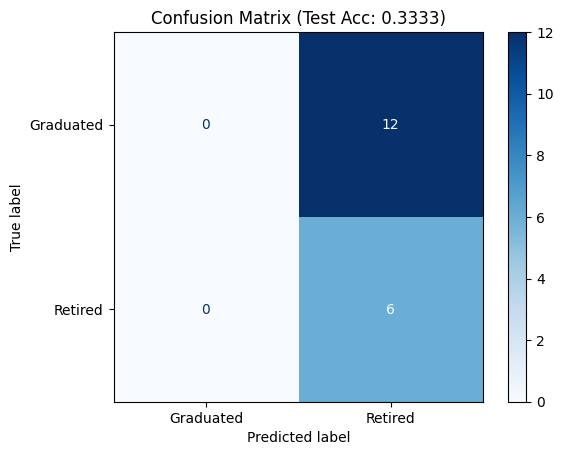

[I 2025-03-10 02:33:07,798] Trial 5 finished with value: 0.6666666567325592 and parameters: {'learning_rate': 3.5498788321965036e-05, 'dropout_rate': 0.2216968971838151, 'weight_decay': 3.752055855124284e-05}. Best is trial 3 with value: 0.2777777910232544.
/var/folders/7g/xvz8wfd9477_ywln21gwjvdr0000gn/T/ipykernel_32054/4043238553.py:102: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  learning_rate = trial.suggest_loguniform('learning_rate', 1e-5, 1e-2)
/var/folders/7g/xvz8wfd9477_ywln21gwjvdr0000gn/T/ipykernel_32054/4043238553.py:103: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  dropout_rate = trial.suggest_uniform('dropout_rate', 0.1, 0.5)
/var/folders/7g/xvz8wfd9477_ywln21gwjvdr0000g

Epoch 01 - Train Loss: 0.6981, Train Acc: 0.5125, Val Loss: 0.6937, Val Acc: 0.3333
Epoch 02 - Train Loss: 0.6959, Train Acc: 0.4250, Val Loss: 0.6939, Val Acc: 0.3333
Epoch 03 - Train Loss: 0.6970, Train Acc: 0.4125, Val Loss: 0.6941, Val Acc: 0.3333
Epoch 04 - Train Loss: 0.6956, Train Acc: 0.4250, Val Loss: 0.6941, Val Acc: 0.3333
Epoch 05 - Train Loss: 0.6961, Train Acc: 0.4125, Val Loss: 0.6941, Val Acc: 0.3333
Epoch 06 - Train Loss: 0.6941, Train Acc: 0.4500, Val Loss: 0.6941, Val Acc: 0.3333
Epoch 07 - Train Loss: 0.6961, Train Acc: 0.4125, Val Loss: 0.6941, Val Acc: 0.3333
Epoch 08 - Train Loss: 0.6936, Train Acc: 0.4375, Val Loss: 0.6941, Val Acc: 0.3333
Epoch 09 - Train Loss: 0.6939, Train Acc: 0.4750, Val Loss: 0.6941, Val Acc: 0.3333
Epoch 10 - Train Loss: 0.6940, Train Acc: 0.4375, Val Loss: 0.6940, Val Acc: 0.3333
Epoch 11 - Train Loss: 0.6930, Train Acc: 0.4875, Val Loss: 0.6940, Val Acc: 0.3333
Epoch 12 - Train Loss: 0.6945, Train Acc: 0.4250, Val Loss: 0.6940, Val Acc:

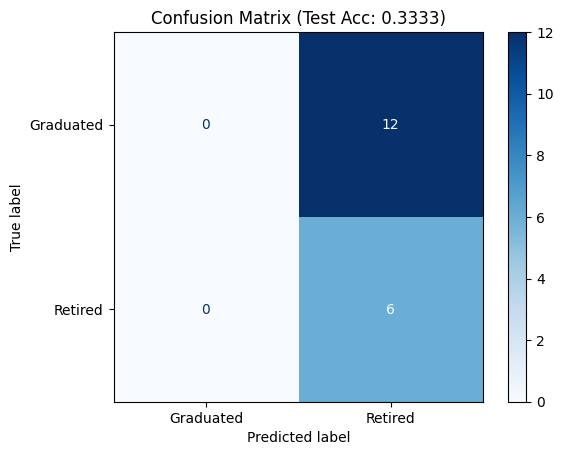

[I 2025-03-10 02:35:31,491] Trial 6 finished with value: 0.6666666567325592 and parameters: {'learning_rate': 0.00019762189340280086, 'dropout_rate': 0.21649165607921678, 'weight_decay': 6.847920095574779e-05}. Best is trial 3 with value: 0.2777777910232544.
/var/folders/7g/xvz8wfd9477_ywln21gwjvdr0000gn/T/ipykernel_32054/4043238553.py:102: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  learning_rate = trial.suggest_loguniform('learning_rate', 1e-5, 1e-2)
/var/folders/7g/xvz8wfd9477_ywln21gwjvdr0000gn/T/ipykernel_32054/4043238553.py:103: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  dropout_rate = trial.suggest_uniform('dropout_rate', 0.1, 0.5)
/var/folders/7g/xvz8wfd9477_ywln21gwjvdr0000

Epoch 01 - Train Loss: 0.7026, Train Acc: 0.5000, Val Loss: 0.6932, Val Acc: 0.3333
Epoch 02 - Train Loss: 0.7035, Train Acc: 0.4250, Val Loss: 0.6933, Val Acc: 0.3333
Epoch 03 - Train Loss: 0.7008, Train Acc: 0.4125, Val Loss: 0.6934, Val Acc: 0.3333
Epoch 04 - Train Loss: 0.7021, Train Acc: 0.4250, Val Loss: 0.6934, Val Acc: 0.3333
Epoch 05 - Train Loss: 0.7008, Train Acc: 0.4125, Val Loss: 0.6934, Val Acc: 0.3333
Epoch 06 - Train Loss: 0.7036, Train Acc: 0.4125, Val Loss: 0.6935, Val Acc: 0.3333
Epoch 07 - Train Loss: 0.7037, Train Acc: 0.4250, Val Loss: 0.6935, Val Acc: 0.3333
Epoch 08 - Train Loss: 0.6996, Train Acc: 0.4250, Val Loss: 0.6935, Val Acc: 0.3333
Epoch 09 - Train Loss: 0.7053, Train Acc: 0.4125, Val Loss: 0.6936, Val Acc: 0.3333
Epoch 10 - Train Loss: 0.7013, Train Acc: 0.4125, Val Loss: 0.6936, Val Acc: 0.3333
Epoch 11 - Train Loss: 0.6975, Train Acc: 0.4250, Val Loss: 0.6937, Val Acc: 0.3333
Epoch 12 - Train Loss: 0.7028, Train Acc: 0.4125, Val Loss: 0.6937, Val Acc:

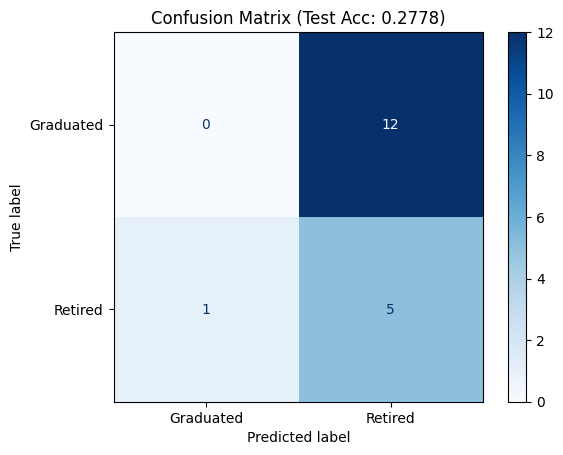

[I 2025-03-10 02:37:44,986] Trial 7 finished with value: 0.7222222089767456 and parameters: {'learning_rate': 2.621087878265438e-05, 'dropout_rate': 0.21685785941408728, 'weight_decay': 1.2562773503807034e-05}. Best is trial 3 with value: 0.2777777910232544.
/var/folders/7g/xvz8wfd9477_ywln21gwjvdr0000gn/T/ipykernel_32054/4043238553.py:102: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  learning_rate = trial.suggest_loguniform('learning_rate', 1e-5, 1e-2)
/var/folders/7g/xvz8wfd9477_ywln21gwjvdr0000gn/T/ipykernel_32054/4043238553.py:103: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  dropout_rate = trial.suggest_uniform('dropout_rate', 0.1, 0.5)
/var/folders/7g/xvz8wfd9477_ywln21gwjvdr0000

Epoch 01 - Train Loss: 0.6842, Train Acc: 0.5875, Val Loss: 0.6939, Val Acc: 0.3333
Epoch 02 - Train Loss: 0.6924, Train Acc: 0.4750, Val Loss: 0.6945, Val Acc: 0.3333
Epoch 03 - Train Loss: 0.6869, Train Acc: 0.4875, Val Loss: 0.6949, Val Acc: 0.3333
Epoch 04 - Train Loss: 0.6814, Train Acc: 0.5125, Val Loss: 0.6952, Val Acc: 0.3333
Epoch 05 - Train Loss: 0.6818, Train Acc: 0.4875, Val Loss: 0.6955, Val Acc: 0.3333
Epoch 06 - Train Loss: 0.6855, Train Acc: 0.4875, Val Loss: 0.6957, Val Acc: 0.3333
Epoch 07 - Train Loss: 0.6853, Train Acc: 0.5000, Val Loss: 0.6959, Val Acc: 0.3333
Epoch 08 - Train Loss: 0.6829, Train Acc: 0.4875, Val Loss: 0.6961, Val Acc: 0.3333
Epoch 09 - Train Loss: 0.6811, Train Acc: 0.5000, Val Loss: 0.6962, Val Acc: 0.3333
Epoch 10 - Train Loss: 0.6843, Train Acc: 0.5000, Val Loss: 0.6963, Val Acc: 0.3333
Epoch 11 - Train Loss: 0.6798, Train Acc: 0.4875, Val Loss: 0.6963, Val Acc: 0.3333
Epoch 12 - Train Loss: 0.6855, Train Acc: 0.5000, Val Loss: 0.6961, Val Acc:

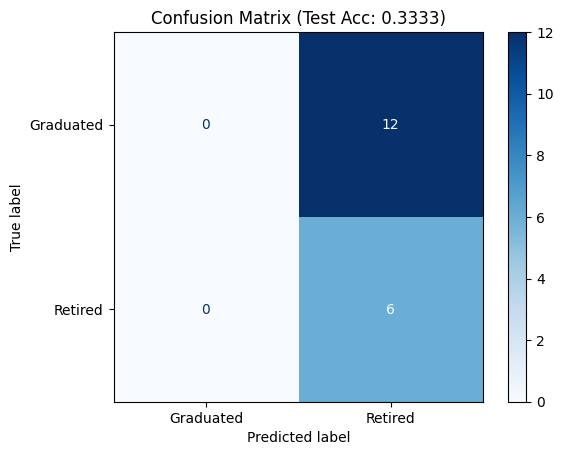

[I 2025-03-10 02:40:04,396] Trial 8 finished with value: 0.6666666567325592 and parameters: {'learning_rate': 0.00023345864076016249, 'dropout_rate': 0.41407038455720546, 'weight_decay': 3.972110727381911e-06}. Best is trial 3 with value: 0.2777777910232544.
/var/folders/7g/xvz8wfd9477_ywln21gwjvdr0000gn/T/ipykernel_32054/4043238553.py:102: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  learning_rate = trial.suggest_loguniform('learning_rate', 1e-5, 1e-2)
/var/folders/7g/xvz8wfd9477_ywln21gwjvdr0000gn/T/ipykernel_32054/4043238553.py:103: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  dropout_rate = trial.suggest_uniform('dropout_rate', 0.1, 0.5)
/var/folders/7g/xvz8wfd9477_ywln21gwjvdr0000

Epoch 01 - Train Loss: 0.6869, Train Acc: 0.5625, Val Loss: 0.6940, Val Acc: 0.3333
Epoch 02 - Train Loss: 0.6878, Train Acc: 0.4750, Val Loss: 0.6937, Val Acc: 0.3333
Epoch 03 - Train Loss: 0.6836, Train Acc: 0.5125, Val Loss: 0.6933, Val Acc: 0.3333
Epoch 04 - Train Loss: 0.6866, Train Acc: 0.4500, Val Loss: 0.6929, Val Acc: 0.6667
Epoch 05 - Train Loss: 0.6868, Train Acc: 0.5125, Val Loss: 0.6925, Val Acc: 0.6667
Epoch 06 - Train Loss: 0.6853, Train Acc: 0.5375, Val Loss: 0.6923, Val Acc: 0.6667
Epoch 07 - Train Loss: 0.6848, Train Acc: 0.6000, Val Loss: 0.6920, Val Acc: 0.6667
Epoch 08 - Train Loss: 0.6823, Train Acc: 0.5500, Val Loss: 0.6918, Val Acc: 0.6667
Epoch 09 - Train Loss: 0.6812, Train Acc: 0.5875, Val Loss: 0.6916, Val Acc: 0.6667
Epoch 10 - Train Loss: 0.6839, Train Acc: 0.5750, Val Loss: 0.6914, Val Acc: 0.6667
Epoch 11 - Train Loss: 0.6793, Train Acc: 0.6125, Val Loss: 0.6912, Val Acc: 0.6667
Epoch 12 - Train Loss: 0.6811, Train Acc: 0.5625, Val Loss: 0.6910, Val Acc:

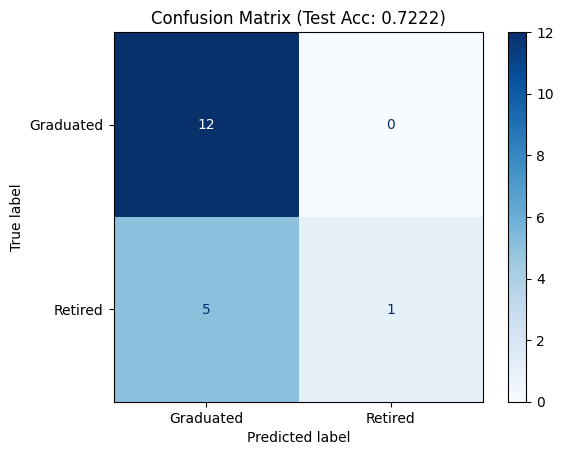

[I 2025-03-10 02:42:16,993] Trial 9 finished with value: 0.2777777910232544 and parameters: {'learning_rate': 0.0003489018845491386, 'dropout_rate': 0.33696582754481696, 'weight_decay': 1.3783237455007196e-06}. Best is trial 3 with value: 0.2777777910232544.
/var/folders/7g/xvz8wfd9477_ywln21gwjvdr0000gn/T/ipykernel_32054/4043238553.py:102: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  learning_rate = trial.suggest_loguniform('learning_rate', 1e-5, 1e-2)
/var/folders/7g/xvz8wfd9477_ywln21gwjvdr0000gn/T/ipykernel_32054/4043238553.py:103: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  dropout_rate = trial.suggest_uniform('dropout_rate', 0.1, 0.5)
/var/folders/7g/xvz8wfd9477_ywln21gwjvdr0000

Epoch 01 - Train Loss: 0.6955, Train Acc: 0.5125, Val Loss: 0.7081, Val Acc: 0.3333
Epoch 02 - Train Loss: 0.6811, Train Acc: 0.5125, Val Loss: 0.6918, Val Acc: 0.6667
Epoch 03 - Train Loss: 0.6689, Train Acc: 0.5625, Val Loss: 0.6708, Val Acc: 0.6667
Epoch 04 - Train Loss: 0.6455, Train Acc: 0.6000, Val Loss: 0.6665, Val Acc: 0.6667
Epoch 05 - Train Loss: 0.6378, Train Acc: 0.5625, Val Loss: 0.6688, Val Acc: 0.6667
Epoch 06 - Train Loss: 0.6252, Train Acc: 0.6250, Val Loss: 0.8557, Val Acc: 0.6667
Epoch 07 - Train Loss: 1.1243, Train Acc: 0.5625, Val Loss: 0.7128, Val Acc: 0.3333
Epoch 08 - Train Loss: 0.6359, Train Acc: 0.5000, Val Loss: 0.7317, Val Acc: 0.3333
Epoch 09 - Train Loss: 0.6499, Train Acc: 0.5000, Val Loss: 0.7131, Val Acc: 0.3333
Epoch 10 - Train Loss: 0.6398, Train Acc: 0.5125, Val Loss: 0.6907, Val Acc: 0.6667
Epoch 11 - Train Loss: 0.6273, Train Acc: 0.5375, Val Loss: 0.6740, Val Acc: 0.6667
Epoch 12 - Train Loss: 0.6350, Train Acc: 0.5625, Val Loss: 0.6632, Val Acc:

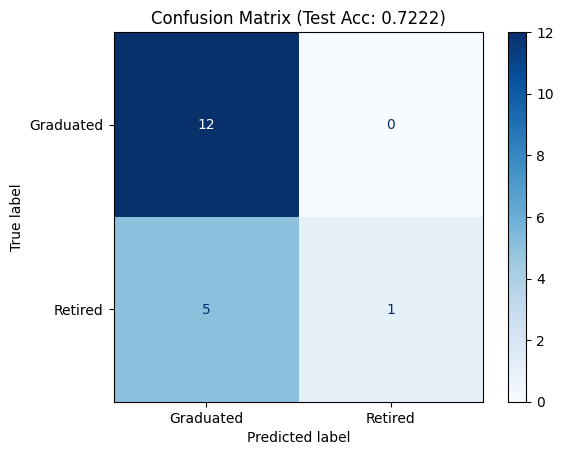

[I 2025-03-10 02:44:36,913] Trial 10 finished with value: 0.2777777910232544 and parameters: {'learning_rate': 0.008013349589915035, 'dropout_rate': 0.10239887318232682, 'weight_decay': 0.0008102356207766662}. Best is trial 3 with value: 0.2777777910232544.
/var/folders/7g/xvz8wfd9477_ywln21gwjvdr0000gn/T/ipykernel_32054/4043238553.py:102: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  learning_rate = trial.suggest_loguniform('learning_rate', 1e-5, 1e-2)
/var/folders/7g/xvz8wfd9477_ywln21gwjvdr0000gn/T/ipykernel_32054/4043238553.py:103: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  dropout_rate = trial.suggest_uniform('dropout_rate', 0.1, 0.5)
/var/folders/7g/xvz8wfd9477_ywln21gwjvdr0000g

Epoch 01 - Train Loss: 0.6893, Train Acc: 0.5625, Val Loss: 0.7036, Val Acc: 0.3333
Epoch 02 - Train Loss: 0.6836, Train Acc: 0.5000, Val Loss: 0.7066, Val Acc: 0.3333
Epoch 03 - Train Loss: 0.6780, Train Acc: 0.5000, Val Loss: 0.7043, Val Acc: 0.3333
Epoch 04 - Train Loss: 0.6677, Train Acc: 0.5125, Val Loss: 0.6999, Val Acc: 0.3333
Epoch 05 - Train Loss: 0.6613, Train Acc: 0.5000, Val Loss: 0.6914, Val Acc: 0.6667
Epoch 06 - Train Loss: 0.6439, Train Acc: 0.5750, Val Loss: 0.6773, Val Acc: 0.6667
Epoch 07 - Train Loss: 0.6352, Train Acc: 0.5750, Val Loss: 0.6596, Val Acc: 0.6667
Epoch 08 - Train Loss: 0.6478, Train Acc: 0.5500, Val Loss: 0.6511, Val Acc: 0.6667
Epoch 09 - Train Loss: 0.6336, Train Acc: 0.5750, Val Loss: 0.6469, Val Acc: 0.6667
Epoch 10 - Train Loss: 0.6406, Train Acc: 0.5875, Val Loss: 0.6443, Val Acc: 0.6667
Epoch 11 - Train Loss: 0.6379, Train Acc: 0.5875, Val Loss: 0.6430, Val Acc: 0.6667
Epoch 12 - Train Loss: 0.6416, Train Acc: 0.5875, Val Loss: 0.6422, Val Acc:

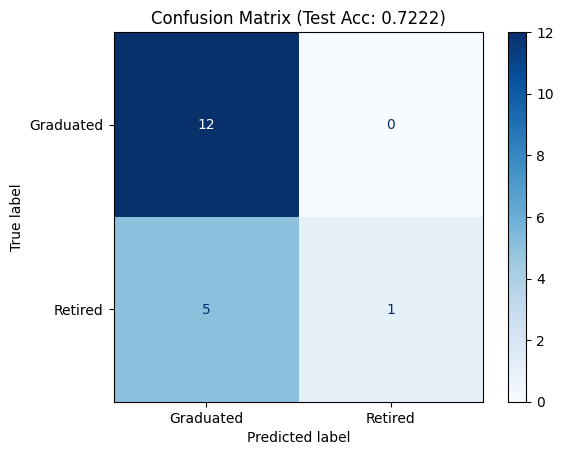

[I 2025-03-10 02:47:12,164] Trial 11 finished with value: 0.2777777910232544 and parameters: {'learning_rate': 0.0030654964608996917, 'dropout_rate': 0.10325450603507945, 'weight_decay': 0.0005284384205738853}. Best is trial 3 with value: 0.2777777910232544.
/var/folders/7g/xvz8wfd9477_ywln21gwjvdr0000gn/T/ipykernel_32054/4043238553.py:102: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  learning_rate = trial.suggest_loguniform('learning_rate', 1e-5, 1e-2)
/var/folders/7g/xvz8wfd9477_ywln21gwjvdr0000gn/T/ipykernel_32054/4043238553.py:103: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  dropout_rate = trial.suggest_uniform('dropout_rate', 0.1, 0.5)
/var/folders/7g/xvz8wfd9477_ywln21gwjvdr0000

Epoch 01 - Train Loss: 0.6972, Train Acc: 0.5250, Val Loss: 0.7024, Val Acc: 0.3333
Epoch 02 - Train Loss: 0.6923, Train Acc: 0.4625, Val Loss: 0.7072, Val Acc: 0.3333
Epoch 03 - Train Loss: 0.6816, Train Acc: 0.5000, Val Loss: 0.7093, Val Acc: 0.3333
Epoch 04 - Train Loss: 0.6841, Train Acc: 0.5000, Val Loss: 0.7102, Val Acc: 0.3333
Epoch 05 - Train Loss: 0.6691, Train Acc: 0.5125, Val Loss: 0.7117, Val Acc: 0.3333
Epoch 06 - Train Loss: 0.6663, Train Acc: 0.4875, Val Loss: 0.7136, Val Acc: 0.3333
Epoch 07 - Train Loss: 0.6705, Train Acc: 0.4875, Val Loss: 0.7133, Val Acc: 0.3333
Epoch 08 - Train Loss: 0.6579, Train Acc: 0.5125, Val Loss: 0.7110, Val Acc: 0.3333
Epoch 09 - Train Loss: 0.6480, Train Acc: 0.5125, Val Loss: 0.7047, Val Acc: 0.3333
Epoch 10 - Train Loss: 0.6469, Train Acc: 0.4875, Val Loss: 0.6924, Val Acc: 0.5556
Epoch 11 - Train Loss: 0.6453, Train Acc: 0.4500, Val Loss: 0.6797, Val Acc: 0.6667
Epoch 12 - Train Loss: 0.6251, Train Acc: 0.6125, Val Loss: 0.6708, Val Acc:

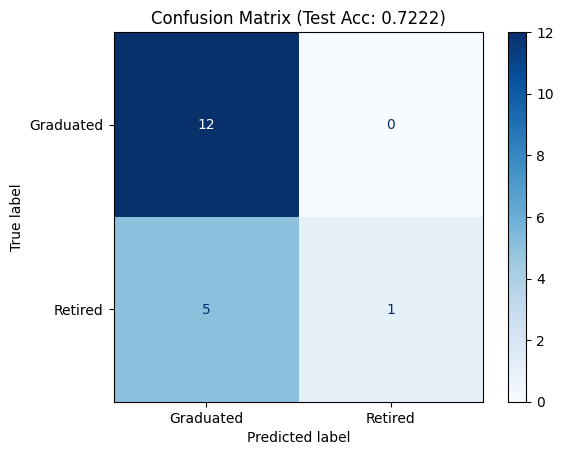

[I 2025-03-10 02:49:40,485] Trial 12 finished with value: 0.2777777910232544 and parameters: {'learning_rate': 0.0021712067088435674, 'dropout_rate': 0.3121417088074112, 'weight_decay': 1.0101492103280279e-05}. Best is trial 3 with value: 0.2777777910232544.
/var/folders/7g/xvz8wfd9477_ywln21gwjvdr0000gn/T/ipykernel_32054/4043238553.py:102: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  learning_rate = trial.suggest_loguniform('learning_rate', 1e-5, 1e-2)
/var/folders/7g/xvz8wfd9477_ywln21gwjvdr0000gn/T/ipykernel_32054/4043238553.py:103: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  dropout_rate = trial.suggest_uniform('dropout_rate', 0.1, 0.5)
/var/folders/7g/xvz8wfd9477_ywln21gwjvdr0000

Epoch 01 - Train Loss: 0.6898, Train Acc: 0.5625, Val Loss: 0.6971, Val Acc: 0.3333
Epoch 02 - Train Loss: 0.6886, Train Acc: 0.5125, Val Loss: 0.6984, Val Acc: 0.3333
Epoch 03 - Train Loss: 0.6840, Train Acc: 0.5125, Val Loss: 0.6992, Val Acc: 0.3333
Epoch 04 - Train Loss: 0.6864, Train Acc: 0.5000, Val Loss: 0.6994, Val Acc: 0.3333
Epoch 05 - Train Loss: 0.6800, Train Acc: 0.5125, Val Loss: 0.6996, Val Acc: 0.3333
Epoch 06 - Train Loss: 0.6791, Train Acc: 0.5250, Val Loss: 0.6995, Val Acc: 0.3333
Epoch 07 - Train Loss: 0.6783, Train Acc: 0.5125, Val Loss: 0.6998, Val Acc: 0.3333
Epoch 08 - Train Loss: 0.6739, Train Acc: 0.5250, Val Loss: 0.6999, Val Acc: 0.3333
Epoch 09 - Train Loss: 0.6748, Train Acc: 0.5000, Val Loss: 0.6995, Val Acc: 0.3333
Epoch 10 - Train Loss: 0.6736, Train Acc: 0.5250, Val Loss: 0.6983, Val Acc: 0.3333
Epoch 11 - Train Loss: 0.6662, Train Acc: 0.5375, Val Loss: 0.6973, Val Acc: 0.3333
Epoch 12 - Train Loss: 0.6602, Train Acc: 0.5000, Val Loss: 0.6950, Val Acc:

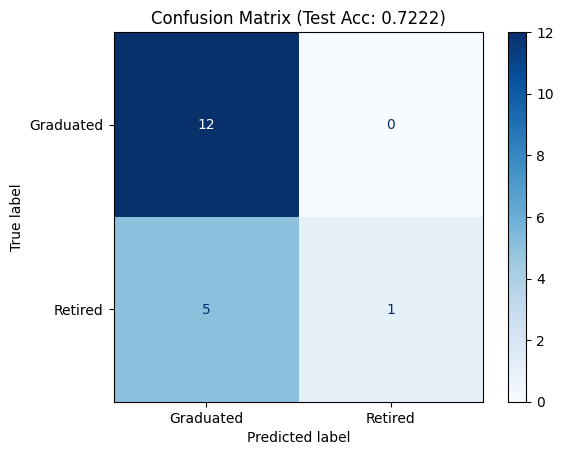

[I 2025-03-10 02:51:58,144] Trial 13 finished with value: 0.2777777910232544 and parameters: {'learning_rate': 0.0014110878546023105, 'dropout_rate': 0.15782302177557267, 'weight_decay': 0.00021240029415411002}. Best is trial 3 with value: 0.2777777910232544.
/var/folders/7g/xvz8wfd9477_ywln21gwjvdr0000gn/T/ipykernel_32054/4043238553.py:102: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  learning_rate = trial.suggest_loguniform('learning_rate', 1e-5, 1e-2)
/var/folders/7g/xvz8wfd9477_ywln21gwjvdr0000gn/T/ipykernel_32054/4043238553.py:103: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  dropout_rate = trial.suggest_uniform('dropout_rate', 0.1, 0.5)
/var/folders/7g/xvz8wfd9477_ywln21gwjvdr000

Epoch 01 - Train Loss: 0.6908, Train Acc: 0.5375, Val Loss: 0.7024, Val Acc: 0.3333
Epoch 02 - Train Loss: 0.6803, Train Acc: 0.5000, Val Loss: 0.6976, Val Acc: 0.3333
Epoch 03 - Train Loss: 0.6642, Train Acc: 0.5625, Val Loss: 0.6587, Val Acc: 0.6667
Epoch 04 - Train Loss: 0.6613, Train Acc: 0.5875, Val Loss: 0.8274, Val Acc: 0.3333
Epoch 05 - Train Loss: 0.6882, Train Acc: 0.5125, Val Loss: 0.6662, Val Acc: 0.6667
Epoch 06 - Train Loss: 0.6394, Train Acc: 0.6000, Val Loss: 0.6550, Val Acc: 0.6667
Epoch 07 - Train Loss: 0.6495, Train Acc: 0.5875, Val Loss: 0.6546, Val Acc: 0.6667
Epoch 08 - Train Loss: 0.6726, Train Acc: 0.5625, Val Loss: 0.6579, Val Acc: 0.6667
Epoch 09 - Train Loss: 0.6519, Train Acc: 0.5875, Val Loss: 0.6608, Val Acc: 0.6667
Epoch 10 - Train Loss: 0.6422, Train Acc: 0.5875, Val Loss: 0.6627, Val Acc: 0.6667
Epoch 11 - Train Loss: 0.6420, Train Acc: 0.6000, Val Loss: 0.6637, Val Acc: 0.6667
Epoch 12 - Train Loss: 0.6567, Train Acc: 0.5875, Val Loss: 0.6666, Val Acc:

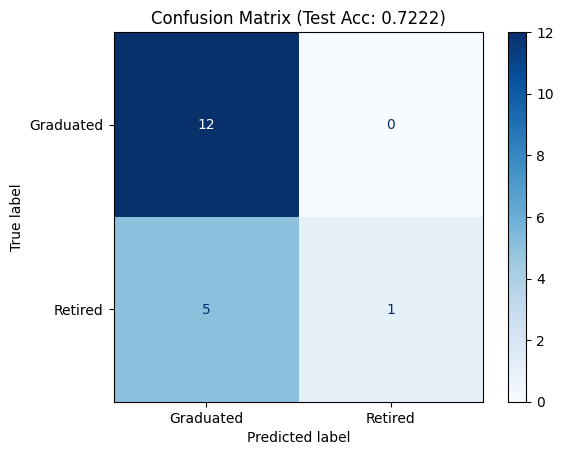

[I 2025-03-10 02:54:25,228] Trial 14 finished with value: 0.2777777910232544 and parameters: {'learning_rate': 0.007379485266686474, 'dropout_rate': 0.15937199128688226, 'weight_decay': 1.0920493146591212e-05}. Best is trial 3 with value: 0.2777777910232544.
/var/folders/7g/xvz8wfd9477_ywln21gwjvdr0000gn/T/ipykernel_32054/4043238553.py:102: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  learning_rate = trial.suggest_loguniform('learning_rate', 1e-5, 1e-2)
/var/folders/7g/xvz8wfd9477_ywln21gwjvdr0000gn/T/ipykernel_32054/4043238553.py:103: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  dropout_rate = trial.suggest_uniform('dropout_rate', 0.1, 0.5)
/var/folders/7g/xvz8wfd9477_ywln21gwjvdr0000

Epoch 01 - Train Loss: 0.6952, Train Acc: 0.5250, Val Loss: 0.6944, Val Acc: 0.3333
Epoch 02 - Train Loss: 0.6968, Train Acc: 0.4125, Val Loss: 0.6938, Val Acc: 0.3333
Epoch 03 - Train Loss: 0.6978, Train Acc: 0.4000, Val Loss: 0.6934, Val Acc: 0.3333
Epoch 04 - Train Loss: 0.6920, Train Acc: 0.4000, Val Loss: 0.6925, Val Acc: 0.6667
Epoch 05 - Train Loss: 0.6887, Train Acc: 0.6125, Val Loss: 0.6916, Val Acc: 0.6667
Epoch 06 - Train Loss: 0.6914, Train Acc: 0.5375, Val Loss: 0.6910, Val Acc: 0.6667
Epoch 07 - Train Loss: 0.6912, Train Acc: 0.5000, Val Loss: 0.6907, Val Acc: 0.6667
Epoch 08 - Train Loss: 0.6868, Train Acc: 0.5375, Val Loss: 0.6903, Val Acc: 0.6667
Epoch 09 - Train Loss: 0.6846, Train Acc: 0.5000, Val Loss: 0.6900, Val Acc: 0.6667
Epoch 10 - Train Loss: 0.6845, Train Acc: 0.6000, Val Loss: 0.6899, Val Acc: 0.6667
Epoch 11 - Train Loss: 0.6793, Train Acc: 0.6125, Val Loss: 0.6898, Val Acc: 0.6667
Epoch 12 - Train Loss: 0.6791, Train Acc: 0.6125, Val Loss: 0.6897, Val Acc:

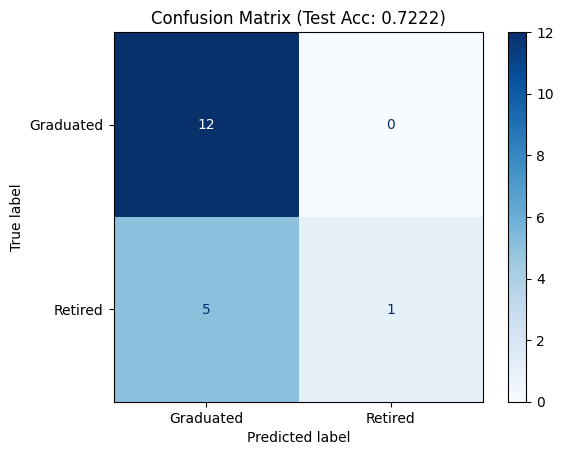

[I 2025-03-10 02:56:35,249] Trial 15 finished with value: 0.2777777910232544 and parameters: {'learning_rate': 0.0007221074562457084, 'dropout_rate': 0.27084492225333273, 'weight_decay': 1.0617683693944125e-06}. Best is trial 3 with value: 0.2777777910232544.
/var/folders/7g/xvz8wfd9477_ywln21gwjvdr0000gn/T/ipykernel_32054/4043238553.py:102: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  learning_rate = trial.suggest_loguniform('learning_rate', 1e-5, 1e-2)
/var/folders/7g/xvz8wfd9477_ywln21gwjvdr0000gn/T/ipykernel_32054/4043238553.py:103: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  dropout_rate = trial.suggest_uniform('dropout_rate', 0.1, 0.5)
/var/folders/7g/xvz8wfd9477_ywln21gwjvdr000

Epoch 01 - Train Loss: 0.7011, Train Acc: 0.4750, Val Loss: 0.6970, Val Acc: 0.3333
Epoch 02 - Train Loss: 0.6900, Train Acc: 0.5500, Val Loss: 0.6998, Val Acc: 0.3333
Epoch 03 - Train Loss: 0.6899, Train Acc: 0.4875, Val Loss: 0.6983, Val Acc: 0.3333
Epoch 04 - Train Loss: 0.6839, Train Acc: 0.4625, Val Loss: 0.6964, Val Acc: 0.3333
Epoch 05 - Train Loss: 0.6739, Train Acc: 0.5500, Val Loss: 0.6932, Val Acc: 0.3333
Epoch 06 - Train Loss: 0.6651, Train Acc: 0.5375, Val Loss: 0.6867, Val Acc: 0.6667
Epoch 07 - Train Loss: 0.6447, Train Acc: 0.5500, Val Loss: 0.6716, Val Acc: 0.6667
Epoch 08 - Train Loss: 0.6431, Train Acc: 0.5500, Val Loss: 0.6599, Val Acc: 0.6667
Epoch 09 - Train Loss: 0.6505, Train Acc: 0.5750, Val Loss: 0.6538, Val Acc: 0.6667
Epoch 10 - Train Loss: 0.6411, Train Acc: 0.5875, Val Loss: 0.6518, Val Acc: 0.6667
Epoch 11 - Train Loss: 0.6484, Train Acc: 0.5875, Val Loss: 0.6509, Val Acc: 0.6667
Epoch 12 - Train Loss: 0.6345, Train Acc: 0.5875, Val Loss: 1.9680, Val Acc:

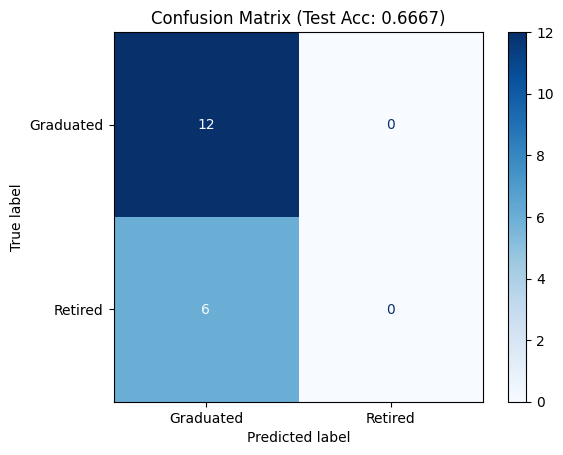

[I 2025-03-10 02:59:10,017] Trial 16 finished with value: 0.3333333134651184 and parameters: {'learning_rate': 0.0036156183431912724, 'dropout_rate': 0.2589950824439845, 'weight_decay': 0.00027911370876240906}. Best is trial 3 with value: 0.2777777910232544.
/var/folders/7g/xvz8wfd9477_ywln21gwjvdr0000gn/T/ipykernel_32054/4043238553.py:102: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  learning_rate = trial.suggest_loguniform('learning_rate', 1e-5, 1e-2)
/var/folders/7g/xvz8wfd9477_ywln21gwjvdr0000gn/T/ipykernel_32054/4043238553.py:103: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  dropout_rate = trial.suggest_uniform('dropout_rate', 0.1, 0.5)
/var/folders/7g/xvz8wfd9477_ywln21gwjvdr0000

Epoch 01 - Train Loss: 0.6943, Train Acc: 0.5375, Val Loss: 0.6971, Val Acc: 0.3333
Epoch 02 - Train Loss: 0.6934, Train Acc: 0.4625, Val Loss: 0.6993, Val Acc: 0.3333
Epoch 03 - Train Loss: 0.6928, Train Acc: 0.4750, Val Loss: 0.7014, Val Acc: 0.3333
Epoch 04 - Train Loss: 0.6893, Train Acc: 0.4875, Val Loss: 0.7033, Val Acc: 0.3333
Epoch 05 - Train Loss: 0.6892, Train Acc: 0.5000, Val Loss: 0.7043, Val Acc: 0.3333
Epoch 06 - Train Loss: 0.6819, Train Acc: 0.5125, Val Loss: 0.7048, Val Acc: 0.3333
Epoch 07 - Train Loss: 0.6849, Train Acc: 0.5125, Val Loss: 0.7051, Val Acc: 0.3333
Epoch 08 - Train Loss: 0.6806, Train Acc: 0.5125, Val Loss: 0.7048, Val Acc: 0.3333
Epoch 09 - Train Loss: 0.6760, Train Acc: 0.5125, Val Loss: 0.7045, Val Acc: 0.3333
Epoch 10 - Train Loss: 0.6756, Train Acc: 0.5125, Val Loss: 0.7033, Val Acc: 0.3333
Epoch 11 - Train Loss: 0.6736, Train Acc: 0.5125, Val Loss: 0.7013, Val Acc: 0.3333
Epoch 12 - Train Loss: 0.6656, Train Acc: 0.5125, Val Loss: 0.6997, Val Acc:

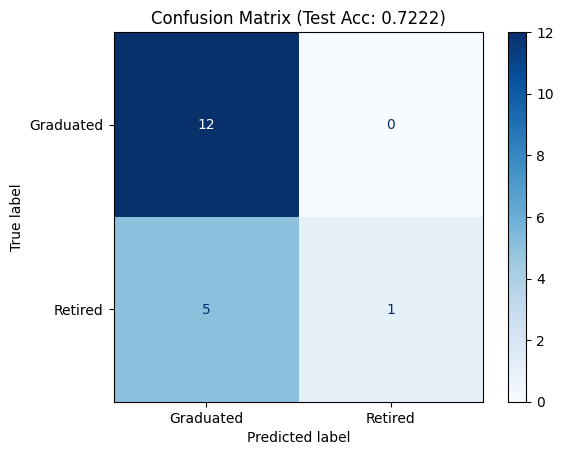

[I 2025-03-10 03:01:50,099] Trial 17 finished with value: 0.2777777910232544 and parameters: {'learning_rate': 0.0010504332534911982, 'dropout_rate': 0.14315866712181177, 'weight_decay': 2.2024931060797153e-05}. Best is trial 3 with value: 0.2777777910232544.
/var/folders/7g/xvz8wfd9477_ywln21gwjvdr0000gn/T/ipykernel_32054/4043238553.py:102: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  learning_rate = trial.suggest_loguniform('learning_rate', 1e-5, 1e-2)
/var/folders/7g/xvz8wfd9477_ywln21gwjvdr0000gn/T/ipykernel_32054/4043238553.py:103: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  dropout_rate = trial.suggest_uniform('dropout_rate', 0.1, 0.5)
/var/folders/7g/xvz8wfd9477_ywln21gwjvdr000

Epoch 01 - Train Loss: 0.6953, Train Acc: 0.5125, Val Loss: 0.7097, Val Acc: 0.3333
Epoch 02 - Train Loss: 0.6816, Train Acc: 0.5000, Val Loss: 0.7134, Val Acc: 0.3333
Epoch 03 - Train Loss: 0.6710, Train Acc: 0.5000, Val Loss: 0.7098, Val Acc: 0.3333
Epoch 04 - Train Loss: 0.6557, Train Acc: 0.5250, Val Loss: 0.6917, Val Acc: 0.6667
Epoch 05 - Train Loss: 0.6427, Train Acc: 0.4625, Val Loss: 0.6765, Val Acc: 0.6667
Epoch 06 - Train Loss: 0.6464, Train Acc: 0.5250, Val Loss: 0.6502, Val Acc: 0.6667
Epoch 07 - Train Loss: 0.6378, Train Acc: 0.5875, Val Loss: 0.6513, Val Acc: 0.6667
Epoch 08 - Train Loss: 0.6430, Train Acc: 0.5875, Val Loss: 0.6536, Val Acc: 0.6667
Epoch 09 - Train Loss: 0.6333, Train Acc: 0.5875, Val Loss: 0.6553, Val Acc: 0.6667
Epoch 10 - Train Loss: 0.6348, Train Acc: 0.5875, Val Loss: 0.6562, Val Acc: 0.6667
Epoch 11 - Train Loss: 0.6359, Train Acc: 0.5875, Val Loss: 0.6573, Val Acc: 0.6667
Epoch 12 - Train Loss: 0.6437, Train Acc: 0.5875, Val Loss: 0.6588, Val Acc:

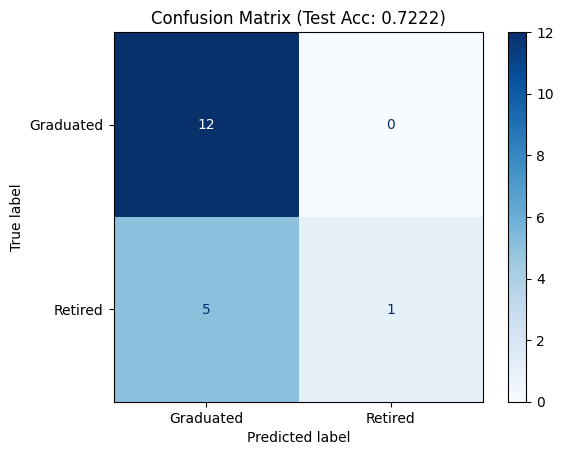

[I 2025-03-10 03:04:29,883] Trial 18 finished with value: 0.2777777910232544 and parameters: {'learning_rate': 0.004259011159635467, 'dropout_rate': 0.19268848959379614, 'weight_decay': 4.210060503334372e-06}. Best is trial 3 with value: 0.2777777910232544.
/var/folders/7g/xvz8wfd9477_ywln21gwjvdr0000gn/T/ipykernel_32054/4043238553.py:102: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  learning_rate = trial.suggest_loguniform('learning_rate', 1e-5, 1e-2)
/var/folders/7g/xvz8wfd9477_ywln21gwjvdr0000gn/T/ipykernel_32054/4043238553.py:103: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  dropout_rate = trial.suggest_uniform('dropout_rate', 0.1, 0.5)
/var/folders/7g/xvz8wfd9477_ywln21gwjvdr0000g

Epoch 01 - Train Loss: 0.7012, Train Acc: 0.5000, Val Loss: 0.6936, Val Acc: 0.3333
Epoch 02 - Train Loss: 0.6985, Train Acc: 0.4250, Val Loss: 0.6937, Val Acc: 0.3333
Epoch 03 - Train Loss: 0.6963, Train Acc: 0.4500, Val Loss: 0.6937, Val Acc: 0.3333
Epoch 04 - Train Loss: 0.6956, Train Acc: 0.4625, Val Loss: 0.6937, Val Acc: 0.3333
Epoch 05 - Train Loss: 0.6942, Train Acc: 0.4625, Val Loss: 0.6938, Val Acc: 0.3333
Epoch 06 - Train Loss: 0.6987, Train Acc: 0.4375, Val Loss: 0.6939, Val Acc: 0.3333
Epoch 07 - Train Loss: 0.6951, Train Acc: 0.4750, Val Loss: 0.6940, Val Acc: 0.3333
Epoch 08 - Train Loss: 0.6999, Train Acc: 0.4000, Val Loss: 0.6942, Val Acc: 0.3333
Epoch 09 - Train Loss: 0.7006, Train Acc: 0.4125, Val Loss: 0.6943, Val Acc: 0.3333
Epoch 10 - Train Loss: 0.6991, Train Acc: 0.4250, Val Loss: 0.6944, Val Acc: 0.3333
Epoch 11 - Train Loss: 0.6937, Train Acc: 0.4375, Val Loss: 0.6945, Val Acc: 0.3333
Epoch 12 - Train Loss: 0.7001, Train Acc: 0.4125, Val Loss: 0.6946, Val Acc:

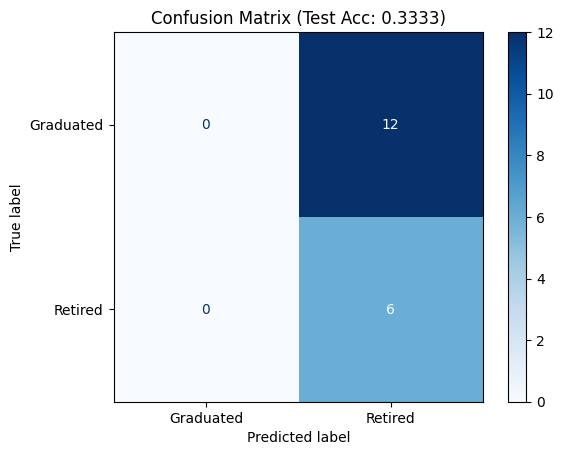

[I 2025-03-10 03:07:08,074] Trial 19 finished with value: 0.6666666567325592 and parameters: {'learning_rate': 0.00010135123215350173, 'dropout_rate': 0.3604063212686379, 'weight_decay': 0.00010040072096533238}. Best is trial 3 with value: 0.2777777910232544.



Best Hyperparameters: {'learning_rate': 0.001331121608073689, 'dropout_rate': 0.10823379771832098, 'weight_decay': 0.0008123245085588687}
Best Test Accuracy: 0.7222


In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
import optuna
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Flatten, LSTM, Dense, Masking, Concatenate, Dropout
from tensorflow.keras.optimizers import AdamW
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from imblearn.over_sampling import RandomOverSampler  

np.random.seed(42)
tf.random.set_seed(42)

if tf.config.list_physical_devices('GPU'):
  device_name = 'GPU'
elif tf.config.list_physical_devices('MPS'):
  device_name = 'MPS'
else:
  device_name = 'CPU'

print(f"Using {device_name} for training.")

for project in issues_cleaned_data:
  issues_cleaned_data[project]['issue_state'] = issues_cleaned_data[project]['issue_state'].map({
      'OPEN': 1, 'CLOSED': 0})

  scaler = MinMaxScaler()
  issues_cleaned_data[project]['days_elapsed'] = scaler.fit_transform(
      issues_cleaned_data[project]['days_elapsed'].values.reshape(-1, 1))

for project in cleaned_data_transformer:
  features = cleaned_data_transformer[project].drop(
      columns=['status'])  # Exclude 'status'
  scaler = MinMaxScaler()
  cleaned_data_transformer[project][features.columns] = scaler.fit_transform(
      features)

X1, X2, y = [], [], []
for project in cleaned_data_transformer:
  df1 = cleaned_data_transformer[project].drop(columns=['status'])
  df2 = issues_cleaned_data[project].drop(columns=['status'])
  X1.append(df1.values)
  X2.append(df2.values)
  y.append(cleaned_data_transformer[project]['status'].iloc[0])

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

X1_padded = pad_sequences(X1, dtype='float32', padding='post', value=-1.0)
X2_padded = pad_sequences(X2, dtype='float32', padding='post', value=-1.0)

(X1_train, X1_temp, X2_train, X2_temp, y_train, y_temp) = train_test_split(
    X1_padded, X2_padded, y_encoded, test_size=0.3, stratify=y_encoded, random_state=42, shuffle=True
)
(X1_val, X1_test, X2_val, X2_test, y_val, y_test) = train_test_split(
    X1_temp, X2_temp, y_temp, test_size=2/3, stratify=y_temp, random_state=42, shuffle=True
)

ros = RandomOverSampler(sampling_strategy='auto', random_state=42)

X1_train_resampled, y_train_resampled = ros.fit_resample(
    X1_train.reshape(X1_train.shape[0], -1), y_train)
X2_train_resampled, _ = ros.fit_resample(
    X2_train.reshape(X2_train.shape[0], -1), y_train)

X1_train_resampled = X1_train_resampled.reshape(
    -1, X1_train.shape[1], X1_train.shape[2])
X2_train_resampled = X2_train_resampled.reshape(
    -1, X2_train.shape[1], X2_train.shape[2])

print(f"Shape of oversampled X1_train: {X1_train_resampled.shape}")
print(f"Shape of oversampled X2_train: {X2_train_resampled.shape}")

class_weights = compute_class_weight(
    class_weight='balanced', classes=np.unique(y_train_resampled), y=y_train_resampled)
class_weight_dict = dict(enumerate(class_weights))
print('class weights: ', class_weight_dict)


def objective(trial):
  learning_rate = trial.suggest_loguniform('learning_rate', 1e-5, 1e-2)
  dropout_rate = trial.suggest_uniform('dropout_rate', 0.1, 0.5)
  weight_decay = trial.suggest_loguniform('weight_decay', 1e-6, 1e-3)

  input1 = Input(shape=(X1_padded.shape[1], X1_padded.shape[2]))
  input2 = Input(shape=(X2_padded.shape[1], X2_padded.shape[2]))

  masked1 = Masking(mask_value=-1.0)(input1)  # Mask padding (0.0)
  masked2 = Masking(mask_value=-1.0)(input2)  # Mask padding (0.0)

  lstm1 = LSTM(64, dropout=dropout_rate)(masked1)
  lstm2 = LSTM(64, dropout=dropout_rate)(masked2)

  concat = Concatenate()([lstm1, lstm2])

  dense = Dense(16, activation='relu',
                kernel_initializer='he_normal')(concat)
  dropout = Dropout(dropout_rate)(dense)

  output = Dense(1, activation='sigmoid',
                 kernel_initializer='glorot_uniform')(dropout)

  model = Model(inputs=[input1, input2], outputs=output)
  optimizer = AdamW(learning_rate=learning_rate, weight_decay=weight_decay)
  model.compile(optimizer=optimizer, loss='binary_crossentropy',
                metrics=['accuracy'])

  with tf.device(f'/device:{device_name}:0'):
    for epoch in range(20):
      history = model.fit(
          [X1_train_resampled, X2_train_resampled], y_train_resampled,
          validation_data=([X1_val, X2_val], y_val),
          epochs=1,
          batch_size=128,
          verbose=0
      )
      train_loss = history.history['loss'][0]
      train_acc = history.history['accuracy'][0]
      val_loss = history.history['val_loss'][0]
      val_acc = history.history['val_accuracy'][0]
      print(f"Epoch {epoch+1:02d} - Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    test_loss, test_acc = model.evaluate([X1_test, X2_test], y_test, verbose=0)
    print(
        f"Test Accuracy: {test_acc:.4f} | Hyperparams: LR={learning_rate:.5f}, Dropout={dropout_rate:.2f}, WD={weight_decay:.6f}")

    y_pred = (model.predict([X1_test, X2_test]) > 0.5).astype("int32")
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm, display_labels=label_encoder.classes_)
    disp.plot(cmap='Blues')
    plt.title(f'Confusion Matrix (Test Acc: {test_acc:.4f})')
    plt.show()

  return 1 - test_acc 


study = optuna.create_study(
    direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=20)

best_params = study.best_params
print(f"\nBest Hyperparameters: {best_params}")

best_test_acc = 1 - study.best_value
print(f"Best Test Accuracy: {best_test_acc:.4f}")